# Multicase-Multiiter

In [131]:
# %%
# ============================================================
# Cell 1. Imports, config, multicase paths
# ============================================================
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import i0
from shapely.geometry import Point, Polygon
from concurrent.futures import ProcessPoolExecutor

RESULTS_ROOT = Path("/home/hschatzle/monte-carlo-selection/results/symmetry/bgmm_butterfly_symmetrical_texture_8")
GEOM_ROOT = Path("/home/hschatzle/monte-carlo-selection/data/cases/symmetry")

CASE_IDS = [f"butterfly_48_symmetrical_8_{i}" for i in range(1, 2)]

TOP_K_CLUSTERS = 5
N_POINTS_SHAPE = 256
N_POINTS_OCCLUDER = 128
FS_SIGNED = True
FS_RESOLUTION = 3
N_WORKERS = 30

print("RESULTS_ROOT:", RESULTS_ROOT)
print("GEOM_ROOT:", GEOM_ROOT)
print("N cases:", len(CASE_IDS))
print("First few CASE_IDS:", CASE_IDS[:3])

RESULTS_ROOT: /home/hschatzle/monte-carlo-selection/results/symmetry/bgmm_butterfly_symmetrical_texture_8
GEOM_ROOT: /home/hschatzle/monte-carlo-selection/data/cases/symmetry
N cases: 1
First few CASE_IDS: ['butterfly_48_symmetrical_8_1']


In [130]:
# %%
# ============================================================
# Cell 2. Helper functions
# ============================================================
def load_jsonl_rows(path: Path):
    rows = []
    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def load_case_from_jsonl(jsonl_path: Path, default_baseGrid: int = 256):
    row = json.loads(jsonl_path.read_text().splitlines()[-1])

    if "silhouette_u" in row:
        sil_u = np.asarray(row["silhouette_u"], float)
        occ_u = np.asarray(row.get("occluder_u", []), float)
        baseGrid = int(row["baseGrid"])
        sil_class = row.get("sil_class", None)
    else:
        sil_u = np.asarray(row["shape_contour_xy"], float)
        occ_u = np.asarray(row.get("occluder_rect_xy", []), float)
        baseGrid = int(row.get("baseGrid", default_baseGrid))
        sil_class = row.get("sil_class", row.get("category", None))

    if occ_u.size == 0:
        occ_u = np.zeros((0, 2), float)

    return sil_u, occ_u, baseGrid, sil_class


def polygon_to_xy(poly, drop_duplicate_endpoint=True):
    poly = np.asarray(poly, dtype=float)

    if poly.ndim != 2:
        raise ValueError(f"Expected 2D polygon array, got shape {poly.shape}")

    if poly.shape[1] == 2:
        xy = poly.copy()
    elif poly.shape[0] == 2:
        xy = poly.T.copy()
    else:
        raise ValueError(f"Could not interpret polygon with shape {poly.shape}")

    if drop_duplicate_endpoint and len(xy) >= 2 and np.allclose(xy[0], xy[-1]):
        xy = xy[:-1]

    return xy


def signed_polygon_area(xy):
    x = xy[:, 0]
    y = xy[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def ensure_ccw(xy):
    return xy[::-1].copy() if signed_polygon_area(xy) < 0 else xy.copy()


def resample_contour_arc_length(xy, n_points=256, closed=True):
    xy = np.asarray(xy, dtype=float)
    assert xy.ndim == 2 and xy.shape[1] == 2, f"Expected (N,2), got {xy.shape}"

    pts = xy.copy()

    if closed:
        if not np.allclose(pts[0], pts[-1]):
            pts = np.vstack([pts, pts[0]])

        diffs = np.diff(pts, axis=0)
        seglen = np.sqrt((diffs ** 2).sum(axis=1))
        s = np.concatenate([[0.0], np.cumsum(seglen)])
        total_len = s[-1]

        if total_len == 0:
            raise ValueError("Degenerate contour with zero total length")

        s_new = np.linspace(0.0, total_len, n_points, endpoint=False)
        x_new = np.interp(s_new, s, pts[:, 0])
        y_new = np.interp(s_new, s, pts[:, 1])
        return np.column_stack([x_new, y_new])

    diffs = np.diff(pts, axis=0)
    seglen = np.sqrt((diffs ** 2).sum(axis=1))
    s = np.concatenate([[0.0], np.cumsum(seglen)])
    total_len = s[-1]

    if total_len == 0:
        raise ValueError("Degenerate contour with zero total length")

    s_new = np.linspace(0.0, total_len, n_points)
    x_new = np.interp(s_new, s, pts[:, 0])
    y_new = np.interp(s_new, s, pts[:, 1])
    return np.column_stack([x_new, y_new])


def contourinfo(x, y, signed=False, resolution=3):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    if len(x) != len(y):
        raise ValueError("x and y must have equal length")

    N = len(x)
    b = 1.0

    if x[0] == x[-1] and y[0] == y[-1]:
        x = x[:-1]
        y = y[:-1]
        N -= 1
        open_curve = False
    else:
        open_curve = True

    normalmap = np.zeros((N, 2), dtype=float)
    surprisalmap = np.zeros(N, dtype=float)

    for j in range(N):
        xprev = 0.0
        yprev = 0.0
        xnext = 0.0
        ynext = 0.0

        for k in range(1, resolution + 1):
            prev_idx = j - k
            next_idx = j + k

            if prev_idx < 0:
                prev_idx += N
            if next_idx >= N:
                next_idx -= N

            xprev += x[prev_idx]
            yprev += y[prev_idx]
            xnext += x[next_idx]
            ynext += y[next_idx]

        xprev /= resolution
        yprev /= resolution
        xnext /= resolution
        ynext /= resolution

        vecprev = np.array([x[j] - xprev, y[j] - yprev], dtype=float)
        vecnext = np.array([xnext - x[j], ynext - y[j]], dtype=float)

        n1 = np.linalg.norm(vecprev)
        n2 = np.linalg.norm(vecnext)

        if n1 == 0 or n2 == 0:
            alpha = 0.0
        else:
            cosv = np.dot(vecprev, vecnext) / (n1 * n2)
            cosv = np.clip(cosv, -1.0, 1.0)
            alpha = np.arccos(cosv)

            cp = vecprev[0] * vecnext[1] - vecprev[1] * vecnext[0]
            alpha = np.sign(cp) * alpha

        if signed:
            shift = 2 * np.pi / (N / resolution)
            surprisal = -np.log(np.exp(b * np.cos(alpha - shift)) / (2 * np.pi * i0(b)))
        else:
            surprisal = -np.log(np.exp(b * np.cos(alpha)) / (2 * np.pi * i0(b)))

        if open_curve and ((j - resolution < 0) or (j + resolution >= N)):
            surprisal = 0.0

        tang = vecprev + vecnext
        tnorm = np.linalg.norm(tang)

        if tnorm == 0:
            normvec = np.array([0.0, 0.0], dtype=float)
        else:
            tang = tang / tnorm
            normvec = np.array([tang[1], -tang[0]], dtype=float)

        normalmap[j] = normvec
        surprisalmap[j] = surprisal

    return surprisalmap, normalmap, x, y, open_curve


def contourinfoplot_arrays(x, y, signed=False, resolution=3):
    surprisal_raw, normalmap, x_used, y_used, open_curve = contourinfo(
        x, y, signed=signed, resolution=resolution
    )

    s_norm = surprisal_raw.copy()
    r = np.ptp(s_norm)
    if r > 0:
        s_norm = (s_norm - s_norm.min()) / r
    else:
        s_norm[:] = 0.0

    needlesize = max(np.ptp(x_used), np.ptp(y_used)) / 10.0

    normal_scaled = normalmap.copy()
    normal_scaled[:, 0] = s_norm * normal_scaled[:, 0]
    normal_scaled[:, 1] = s_norm * normal_scaled[:, 1]

    xnormals = np.column_stack([x_used, x_used + needlesize * normal_scaled[:, 0]])
    ynormals = np.column_stack([y_used, y_used + needlesize * normal_scaled[:, 1]])

    return s_norm, surprisal_raw, normalmap, xnormals, ynormals


def arc_length_inside_mask(xy, mask):
    xy = np.asarray(xy, float)
    mask = np.asarray(mask, bool)

    pts2 = np.vstack([xy, xy[0]])
    diffs = np.diff(pts2, axis=0)
    seglen = np.sqrt((diffs ** 2).sum(axis=1))

    mask_next = np.roll(mask, -1)
    seg_inside = mask & mask_next

    return float(seglen[seg_inside].sum())


def responsibility_dict_from_top5(resp_top5):
    out = {}
    for d in resp_top5:
        out[int(d["k"])] = float(d["p"])
    return out

In [132]:
# %%
# ============================================================
# Cell 3. Parallel worker setup for per-shape FS computation
# ============================================================
_POLYGONS = None
_OCC_POLY = None
_N_POINTS_SHAPE = None
_FS_SIGNED = None
_FS_RESOLUTION = None


def _init_fs_worker(polygons_shared, occ_coords_shared, n_points_shape_shared, fs_signed_shared, fs_resolution_shared):
    global _POLYGONS, _OCC_POLY, _N_POINTS_SHAPE, _FS_SIGNED, _FS_RESOLUTION
    _POLYGONS = polygons_shared
    _OCC_POLY = Polygon(np.asarray(occ_coords_shared, dtype=float))
    if not _OCC_POLY.is_valid:
        _OCC_POLY = _OCC_POLY.buffer(0)
    _N_POINTS_SHAPE = int(n_points_shape_shared)
    _FS_SIGNED = bool(fs_signed_shared)
    _FS_RESOLUTION = int(fs_resolution_shared)


def _worker_compute_fs_metric(task):
    row = task

    global_index = int(row["global_index"])
    k_argmax = int(row["k_argmax"])
    k_rank_among_active = row.get("k_rank_among_active", None)

    xy = polygon_to_xy(_POLYGONS[global_index], drop_duplicate_endpoint=True)
    xy = ensure_ccw(xy)
    xy_res = resample_contour_arc_length(xy, n_points=_N_POINTS_SHAPE, closed=True)

    _, surprisal_raw, _, _, _ = contourinfoplot_arrays(
        xy_res[:, 0],
        xy_res[:, 1],
        signed=_FS_SIGNED,
        resolution=_FS_RESOLUTION
    )

    inside_occ = np.array(
        [_OCC_POLY.covers(Point(x, y)) for x, y in xy_res],
        dtype=bool
    )

    n_inside = int(inside_occ.sum())
    fs_inside_sum = float(np.sum(surprisal_raw[inside_occ])) if n_inside > 0 else 0.0
    fs_inside_mean = float(np.mean(surprisal_raw[inside_occ])) if n_inside > 0 else np.nan
    fs_inside_max = float(np.max(surprisal_raw[inside_occ])) if n_inside > 0 else np.nan
    fs_inside_min = float(np.min(surprisal_raw[inside_occ])) if n_inside > 0 else np.nan

    arclen_inside = arc_length_inside_mask(xy_res, inside_occ)
    fs_inside_density = fs_inside_sum / arclen_inside if arclen_inside > 0 else np.nan

    resp_dict = responsibility_dict_from_top5(row["resp_top5"])

    return {
        "case_id": row["case_id"],
        "eligible_row": int(row["eligible_row"]),
        "global_index": global_index,
        "png": row["png"],
        "k_argmax": k_argmax,
        "k_rank_among_active": k_rank_among_active,
        "n_inside": n_inside,
        "fs_inside_sum": fs_inside_sum,
        "fs_inside_mean": fs_inside_mean,
        "fs_inside_max": fs_inside_max,
        "fs_inside_min": fs_inside_min,
        "arclen_inside": arclen_inside,
        "fs_inside_density": fs_inside_density,
        "resp_dict": resp_dict,
    }

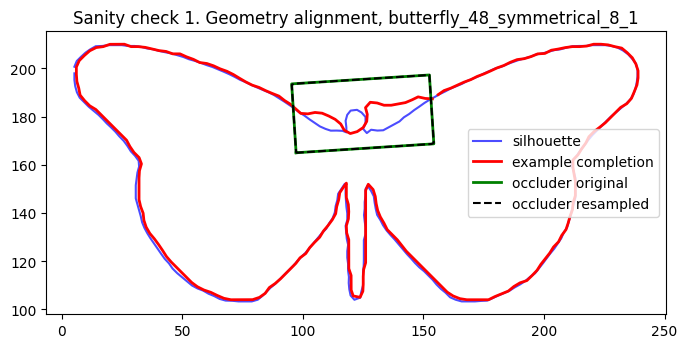

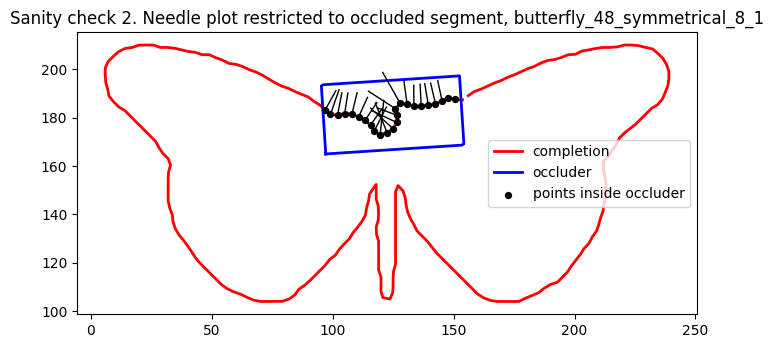

Sanity case: butterfly_48_symmetrical_8_1
baseGrid_case: 256
sil_class: butterfly
example_idx: 0
example k_argmax: 58
n_inside: 24
fs_inside_sum: 28.561482747904027
fs_inside_mean: 1.1900617811626677
fs_inside_arclen: 67.97962216267281


In [133]:
# %%
# ============================================================
# Cell 4. One-case sanity check before the big loop
# ============================================================
SANITY_CASE_ID = CASE_IDS[0]

case_dir = RESULTS_ROOT / SANITY_CASE_ID
geom_dir = GEOM_ROOT / SANITY_CASE_ID

jsonl_path = geom_dir / "generated" / f"{SANITY_CASE_ID}.jsonl"
shapes_npz = geom_dir / "generated" / "shapes_xy.npz"
components_jsonl = case_dir / "components.jsonl"
shape_to_cluster_jsonl = case_dir / "shape_to_cluster.jsonl"

assert jsonl_path.exists(), f"Missing {jsonl_path}"
assert shapes_npz.exists(), f"Missing {shapes_npz}"
assert components_jsonl.exists(), f"Missing {components_jsonl}"
assert shape_to_cluster_jsonl.exists(), f"Missing {shape_to_cluster_jsonl}"

sil_u, occ_u, baseGrid_case, sil_class = load_case_from_jsonl(jsonl_path)
sil_px = sil_u * baseGrid_case
occ_px = occ_u * baseGrid_case
occ_px_resampled = resample_contour_arc_length(
    ensure_ccw(occ_px),
    n_points=N_POINTS_OCCLUDER,
    closed=True
)
occ_poly = Polygon(occ_px_resampled)
if not occ_poly.is_valid:
    occ_poly = occ_poly.buffer(0)

npz = np.load(shapes_npz, allow_pickle=True)
polygons = npz["polygons"]

df_comp = pd.DataFrame(load_jsonl_rows(components_jsonl))
df_shape = pd.DataFrame(load_jsonl_rows(shape_to_cluster_jsonl))

df_comp_active = df_comp[df_comp["is_active"] == True].copy()
df_comp_sel = df_comp_active[df_comp_active["active_rank_by_mass_debias"] <= TOP_K_CLUSTERS].copy()
df_comp_sel = df_comp_sel.sort_values("active_rank_by_mass_debias").reset_index(drop=True)
selected_ks = set(df_comp_sel["k"].astype(int).tolist())

example_row = df_shape[df_shape["k_argmax"].isin(selected_ks)].iloc[0]
example_idx = int(example_row["global_index"])

xy_example = polygon_to_xy(polygons[example_idx], drop_duplicate_endpoint=True)
xy_example = ensure_ccw(xy_example)
xy_example_res = resample_contour_arc_length(xy_example, n_points=N_POINTS_SHAPE, closed=True)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(sil_px[:, 0], sil_px[:, 1], color="blue", lw=1.5, alpha=0.7, label="silhouette")
ax.plot(xy_example_res[:, 0], xy_example_res[:, 1], color="red", lw=2, label="example completion")

occ_closed = np.vstack([occ_px, occ_px[0]])
ax.plot(occ_closed[:, 0], occ_closed[:, 1], color="green", lw=2, label="occluder original")

occ_res_closed = np.vstack([occ_px_resampled, occ_px_resampled[0]])
ax.plot(occ_res_closed[:, 0], occ_res_closed[:, 1], color="black", lw=1.5, linestyle="--", label="occluder resampled")

ax.set_aspect("equal")
ax.set_title(f"Sanity check 1. Geometry alignment, {SANITY_CASE_ID}")
ax.legend()
plt.show()

s_norm_ex, surprisal_raw_ex, normalmap_ex, xnormals_ex, ynormals_ex = contourinfoplot_arrays(
    xy_example_res[:, 0],
    xy_example_res[:, 1],
    signed=FS_SIGNED,
    resolution=FS_RESOLUTION
)

inside_occ_ex = np.array([occ_poly.covers(Point(x, y)) for x, y in xy_example_res], dtype=bool)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(xy_example_res[:, 0], xy_example_res[:, 1], color="red", lw=2, label="completion")
ax.plot(occ_res_closed[:, 0], occ_res_closed[:, 1], color="blue", lw=2, label="occluder")

idx_inside_ex = np.where(inside_occ_ex)[0]
for i in idx_inside_ex:
    ax.plot(xnormals_ex[i], ynormals_ex[i], color="black", lw=1)

ax.scatter(
    xy_example_res[idx_inside_ex, 0],
    xy_example_res[idx_inside_ex, 1],
    s=18,
    color="black",
    zorder=3,
    label="points inside occluder"
)

ax.set_aspect("equal")
ax.set_title(f"Sanity check 2. Needle plot restricted to occluded segment, {SANITY_CASE_ID}")
ax.legend()
plt.show()

print("Sanity case:", SANITY_CASE_ID)
print("baseGrid_case:", baseGrid_case)
print("sil_class:", sil_class)
print("example_idx:", example_idx)
print("example k_argmax:", int(example_row["k_argmax"]))
print("n_inside:", int(inside_occ_ex.sum()))
print("fs_inside_sum:", float(np.sum(surprisal_raw_ex[inside_occ_ex])))
print("fs_inside_mean:", float(np.mean(surprisal_raw_ex[inside_occ_ex])) if inside_occ_ex.any() else np.nan)
print("fs_inside_arclen:", arc_length_inside_mask(xy_example_res, inside_occ_ex))

In [134]:
# %%
# ============================================================
# Cell 5. Per-case processor
# ============================================================
def process_case(case_id: str):
    case_dir = RESULTS_ROOT / case_id
    geom_dir = GEOM_ROOT / case_id

    jsonl_path = geom_dir / "generated" / f"{case_id}.jsonl"
    shapes_npz = geom_dir / "generated" / "shapes_xy.npz"
    components_jsonl = case_dir / "components.jsonl"
    shape_to_cluster_jsonl = case_dir / "shape_to_cluster.jsonl"

    assert jsonl_path.exists(), f"Missing {jsonl_path}"
    assert shapes_npz.exists(), f"Missing {shapes_npz}"
    assert components_jsonl.exists(), f"Missing {components_jsonl}"
    assert shape_to_cluster_jsonl.exists(), f"Missing {shape_to_cluster_jsonl}"

    sil_u, occ_u, baseGrid_case, sil_class = load_case_from_jsonl(jsonl_path)
    sil_px = sil_u * baseGrid_case
    occ_px = occ_u * baseGrid_case

    occ_px_resampled = resample_contour_arc_length(
        ensure_ccw(occ_px),
        n_points=N_POINTS_OCCLUDER,
        closed=True
    )

    occ_poly = Polygon(occ_px_resampled)
    if not occ_poly.is_valid:
        occ_poly = occ_poly.buffer(0)

    npz = np.load(shapes_npz, allow_pickle=True)
    polygons = npz["polygons"]

    df_comp = pd.DataFrame(load_jsonl_rows(components_jsonl))
    df_shape = pd.DataFrame(load_jsonl_rows(shape_to_cluster_jsonl))

    df_comp_active = df_comp[df_comp["is_active"] == True].copy()
    df_comp_sel = df_comp_active[df_comp_active["active_rank_by_mass_debias"] <= TOP_K_CLUSTERS].copy()
    df_comp_sel = df_comp_sel.sort_values("active_rank_by_mass_debias").reset_index(drop=True)

    assert len(df_comp_sel) > 0, f"No selected active clusters for {case_id}"

    selected_ks = set(df_comp_sel["k"].astype(int).tolist())

    mass_sum = df_comp_sel["mass_debias"].sum()
    df_comp_sel["cluster_weight"] = df_comp_sel["mass_debias"] / mass_sum

    df_shape_sel = df_shape[df_shape["k_argmax"].isin(selected_ks)].copy().reset_index(drop=True)

    tasks = df_shape_sel.to_dict(orient="records")
    occ_coords_shared = np.asarray(occ_poly.exterior.coords[:-1], dtype=float)

    with ProcessPoolExecutor(
        max_workers=N_WORKERS,
        initializer=_init_fs_worker,
        initargs=(
            polygons,
            occ_coords_shared,
            N_POINTS_SHAPE,
            FS_SIGNED,
            FS_RESOLUTION,
        ),
    ) as ex:
        rows_metrics = list(ex.map(_worker_compute_fs_metric, tasks, chunksize=32))

    df_metrics = pd.DataFrame(rows_metrics)

    cluster_hard = (
        df_metrics
        .groupby("k_argmax", as_index=False)
        .agg(
            n_shapes=("global_index", "count"),
            mean_fs_inside_sum=("fs_inside_sum", "mean"),
            mean_fs_inside_mean=("fs_inside_mean", "mean"),
            mean_fs_inside_density=("fs_inside_density", "mean"),
            mean_n_inside=("n_inside", "mean"),
            mean_arclen_inside=("arclen_inside", "mean"),
        )
        .rename(columns={"k_argmax": "k"})
    )

    cluster_hard = cluster_hard.merge(
        df_comp_sel[["k", "active_rank_by_mass_debias", "mass_debias", "cluster_weight"]],
        on="k",
        how="left"
    )

    cluster_hard["weighted_sum_metric"] = cluster_hard["cluster_weight"] * cluster_hard["mean_fs_inside_sum"]
    cluster_hard["weighted_mean_metric"] = cluster_hard["cluster_weight"] * cluster_hard["mean_fs_inside_mean"]
    cluster_hard["weighted_density_metric"] = cluster_hard["cluster_weight"] * cluster_hard["mean_fs_inside_density"]

    expected_fs_hard_sum = float(cluster_hard["weighted_sum_metric"].sum())
    expected_fs_hard_mean = float(cluster_hard["weighted_mean_metric"].sum())
    expected_fs_hard_density = float(cluster_hard["weighted_density_metric"].sum())

    soft_rows = []
    for _, row in df_metrics.iterrows():
        for k, p in row["resp_dict"].items():
            if k in selected_ks:
                soft_rows.append({
                    "global_index": row["global_index"],
                    "k": int(k),
                    "resp_p": float(p),
                    "fs_inside_sum": float(row["fs_inside_sum"]),
                    "fs_inside_mean": float(row["fs_inside_mean"]) if pd.notnull(row["fs_inside_mean"]) else np.nan,
                    "fs_inside_density": float(row["fs_inside_density"]) if pd.notnull(row["fs_inside_density"]) else np.nan,
                })

    df_soft = pd.DataFrame(soft_rows)

    soft_group = (
        df_soft
        .groupby("k", as_index=False)
        .apply(
            lambda g: pd.Series({
                "resp_mass_seen": g["resp_p"].sum(),
                "soft_mean_fs_inside_sum": np.average(g["fs_inside_sum"], weights=g["resp_p"]) if g["resp_p"].sum() > 0 else np.nan,
                "soft_mean_fs_inside_mean": np.average(g["fs_inside_mean"].dropna(), weights=g.loc[g["fs_inside_mean"].notna(), "resp_p"]) if g["fs_inside_mean"].notna().any() else np.nan,
                "soft_mean_fs_inside_density": np.average(g["fs_inside_density"].dropna(), weights=g.loc[g["fs_inside_density"].notna(), "resp_p"]) if g["fs_inside_density"].notna().any() else np.nan,
            })
        )
        .reset_index(drop=True)
    )

    soft_group = soft_group.merge(
        df_comp_sel[["k", "active_rank_by_mass_debias", "mass_debias", "cluster_weight"]],
        on="k",
        how="left"
    )

    soft_group["weighted_sum_metric"] = soft_group["cluster_weight"] * soft_group["soft_mean_fs_inside_sum"]
    soft_group["weighted_mean_metric"] = soft_group["cluster_weight"] * soft_group["soft_mean_fs_inside_mean"]
    soft_group["weighted_density_metric"] = soft_group["cluster_weight"] * soft_group["soft_mean_fs_inside_density"]

    expected_fs_soft_sum = float(soft_group["weighted_sum_metric"].sum())
    expected_fs_soft_mean = float(soft_group["weighted_mean_metric"].sum())
    expected_fs_soft_density = float(soft_group["weighted_density_metric"].sum())

    summary_case = {
        "case_id": case_id,
        "top_k_clusters": TOP_K_CLUSTERS,
        "n_selected_clusters": len(selected_ks),
        "n_shapes_selected_hard": len(df_metrics),
        "expected_fs_hard_sum": expected_fs_hard_sum,
        "expected_fs_hard_mean": expected_fs_hard_mean,
        "expected_fs_hard_density": expected_fs_hard_density,
        "expected_fs_soft_sum": expected_fs_soft_sum,
        "expected_fs_soft_mean": expected_fs_soft_mean,
        "expected_fs_soft_density": expected_fs_soft_density,
        "fs_signed": FS_SIGNED,
        "fs_resolution": FS_RESOLUTION,
        "n_points_shape": N_POINTS_SHAPE,
        "n_points_occluder": N_POINTS_OCCLUDER,
    }

    return summary_case

In [135]:
# %%
# ============================================================
# Cell 6. Run all 15 cases
# ============================================================
all_summaries = []

for case_id in CASE_IDS:
    print(f"Processing {case_id} ...")
    summary_case = process_case(case_id)
    all_summaries.append(summary_case)

summary_all = pd.DataFrame(all_summaries)
display(summary_all)

Processing butterfly_48_symmetrical_8_1 ...


,case_id,top_k_clusters,n_selected_clusters,n_shapes_selected_hard,expected_fs_hard_sum,expected_fs_hard_mean,expected_fs_hard_density,expected_fs_soft_sum,expected_fs_soft_mean,expected_fs_soft_density,fs_signed,fs_resolution,n_points_shape,n_points_occluder
0,butterfly_48_symmetrical_8_1,5,5,7087,32.069685,1.174081,0.413424,31.949825,1.172879,0.413099,True,3,256,128


In [136]:
# %%
# ============================================================
# Cell 7. Aggregate across the 15 runs
# ============================================================
metric_cols = [
    "expected_fs_hard_sum",
    "expected_fs_hard_mean",
    "expected_fs_hard_density",
    "expected_fs_soft_sum",
    "expected_fs_soft_mean",
    "expected_fs_soft_density",
    "n_shapes_selected_hard",
]

rows = []
n_cases = len(summary_all)

for col in metric_cols:
    vals = summary_all[col].astype(float).to_numpy()
    mean = float(np.mean(vals))
    sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    se = float(sd / np.sqrt(len(vals))) if len(vals) > 0 else np.nan

    rows.append({
        "metric": col,
        "n_cases": n_cases,
        "mean": mean,
        "sd": sd,
        "se": se,
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
    })

summary_agg = pd.DataFrame(rows)
display(summary_agg)

,metric,n_cases,mean,sd,se,min,max
0,expected_fs_hard_sum,1,32.069685,0.0,0.0,32.069685,32.069685
1,expected_fs_hard_mean,1,1.174081,0.0,0.0,1.174081,1.174081
2,expected_fs_hard_density,1,0.413424,0.0,0.0,0.413424,0.413424
3,expected_fs_soft_sum,1,31.949825,0.0,0.0,31.949825,31.949825
4,expected_fs_soft_mean,1,1.172879,0.0,0.0,1.172879,1.172879
5,expected_fs_soft_density,1,0.413099,0.0,0.0,0.413099,0.413099
6,n_shapes_selected_hard,1,7087.000000,0.0,0.0,7087.000000,7087.000000


In [137]:
# %%
# ============================================================
# Cell 8. Primary result extraction
# - the main cross-run estimate is the average FS density
# ============================================================
primary = summary_agg[summary_agg["metric"] == "expected_fs_hard_density"].iloc[0]

print("Primary metric across 15 runs")
print("metric :", primary["metric"])
print("n_cases:", int(primary["n_cases"]))
print("mean   :", float(primary["mean"]))
print("sd     :", float(primary["sd"]))
print("se     :", float(primary["se"]))
print("min    :", float(primary["min"]))
print("max    :", float(primary["max"]))

Primary metric across 15 runs
metric : expected_fs_hard_density
n_cases: 1
mean   : 0.413424120404694
sd     : 0.0
se     : 0.0
min    : 0.413424120404694
max    : 0.413424120404694


In [118]:
# %%
# ============================================================
# Cell 9. Optional save
# ============================================================
OUT_DIR = RESULTS_ROOT / "_multicase_fs_summary"
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_all.to_csv(OUT_DIR / "summary_all_cases.csv", index=False)
summary_agg.to_csv(OUT_DIR / "summary_aggregate.csv", index=False)

with open(OUT_DIR / "config.json", "w") as f:
    json.dump({
        "results_root": str(RESULTS_ROOT),
        "geom_root": str(GEOM_ROOT),
        "case_ids": CASE_IDS,
        "top_k_clusters": TOP_K_CLUSTERS,
        "n_points_shape": N_POINTS_SHAPE,
        "n_points_occluder": N_POINTS_OCCLUDER,
        "fs_signed": FS_SIGNED,
        "fs_resolution": FS_RESOLUTION,
        "n_workers": N_WORKERS,
    }, f, indent=2)

print("Saved to:", OUT_DIR)

Saved to: /home/hschatzle/monte-carlo-selection/results/symmetry/bgmm_butterfly_symmetrical_texture_6/_multicase_fs_summary


# Visualization

,case_id,top_k_clusters,n_selected_clusters,n_shapes_selected_hard,expected_fs_hard_sum,expected_fs_hard_mean,expected_fs_hard_density,expected_fs_soft_sum,expected_fs_soft_mean,expected_fs_soft_density,fs_signed,fs_resolution,n_points_shape,n_points_occluder,condition,network,info,size
0,elephant_7_low_large_1,5,5,8285,23.133745,1.109074,0.221904,23.013441,1.107075,0.221530,True,3,256,128,bgmm_elephant_texture_low_large,texture,low,large
1,elephant_7_low_large_2,5,5,5928,21.922787,1.088095,0.218253,21.623269,1.081983,0.217104,True,3,256,128,bgmm_elephant_texture_low_large,texture,low,large
2,elephant_7_low_large_3,5,5,7856,22.968000,1.107928,0.222033,22.845523,1.105760,0.221646,True,3,256,128,bgmm_elephant_texture_low_large,texture,low,large
3,elephant_7_low_large_4,5,5,6404,22.267472,1.093583,0.219324,22.088423,1.090040,0.218675,True,3,256,128,bgmm_elephant_texture_low_large,texture,low,large
4,elephant_7_low_large_5,5,5,7183,22.615122,1.100165,0.220583,22.505774,1.098423,0.220302,True,3,256,128,bgmm_elephant_texture_low_large,texture,low,large



Aggregated summary:


,network,info,size,n_runs,fs_density_mean,fs_density_sd,fs_density_se,fs_mean_mean,fs_sum_mean
0,texture,low,small,15,0.206257,0.019455,0.005023,0.796007,5.058350
1,texture,high,small,15,0.216160,0.005350,0.001381,0.847761,5.590527
2,shape,low,small,15,0.201396,0.005458,0.001409,0.799994,4.954970
3,shape,high,small,15,0.265682,0.003634,0.000938,1.054207,8.818684
4,texture,low,large,15,0.219903,0.002202,0.000568,1.096921,22.427604
5,texture,high,large,15,0.250206,0.001842,0.000476,1.245194,31.120773
6,shape,low,large,15,0.237949,0.005400,0.001394,1.195726,27.571767
7,shape,high,large,15,0.241830,0.001962,0.000506,1.195310,27.932943


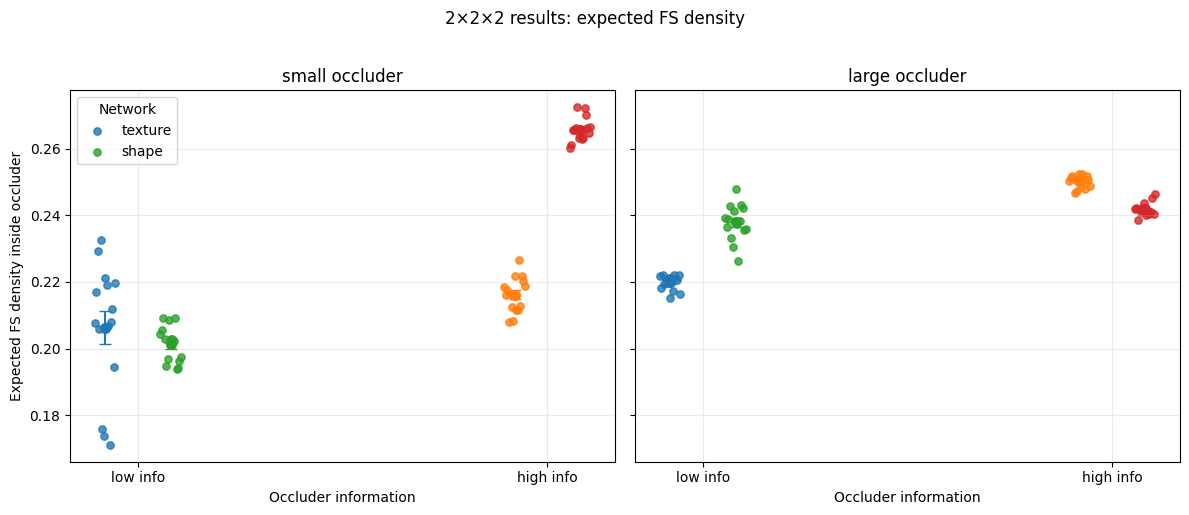

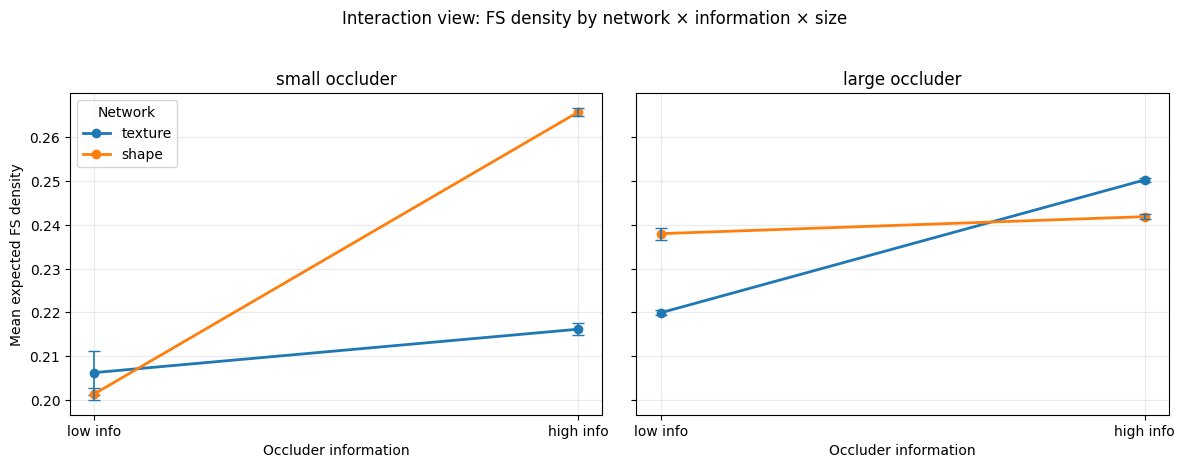

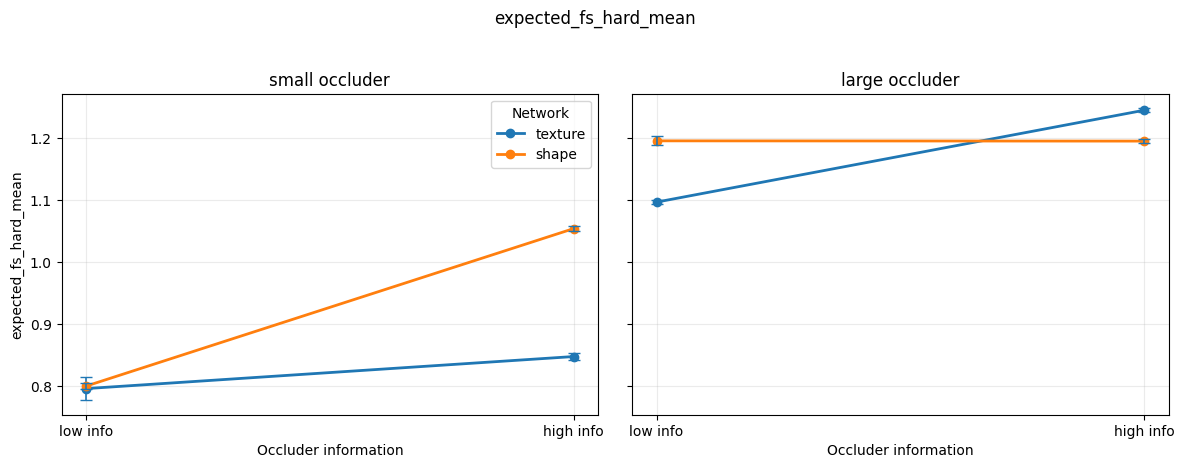

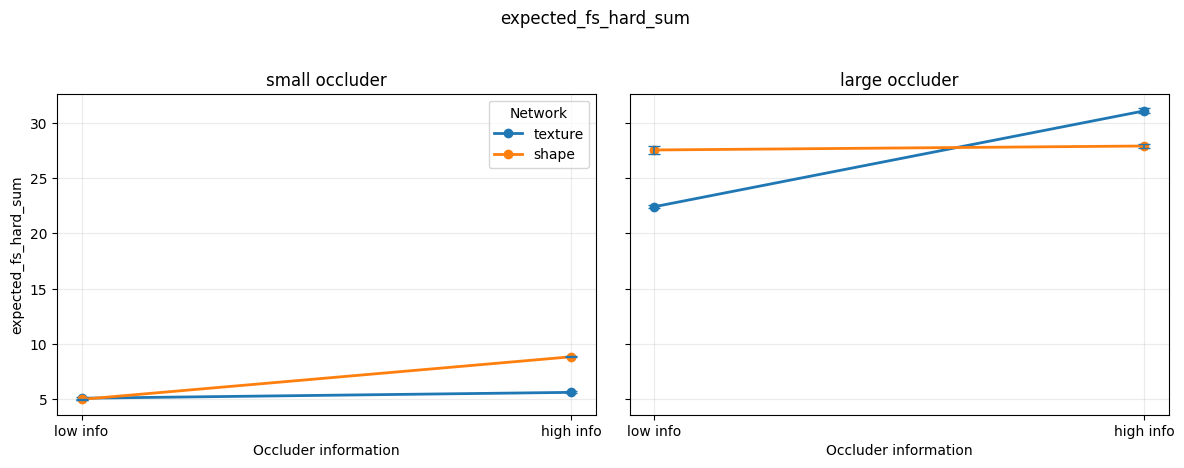

In [78]:
# %%
# ============================================================
# Plot 2x2x2 results from multicase CSV summaries
# - reads summary_all_cases.csv from each condition folder
# - plots per-run points + condition means for:
#     expected_fs_hard_density   (primary)
#     expected_fs_hard_mean
#     expected_fs_hard_sum
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/home/hschatzle/monte-carlo-selection/results/contrasts")

CONDITION_DIRS = [
    "bgmm_elephant_texture_low_large",
    "bgmm_elephant_shape_low_large",
    "bgmm_elephant_texture_high_large",
    "bgmm_elephant_shape_high_large",
    "bgmm_elephant_texture_low_small",
    "bgmm_elephant_shape_low_small",
    "bgmm_elephant_texture_high_small",
    "bgmm_elephant_shape_high_small",
]

PRIMARY_METRIC = "expected_fs_hard_density"
OTHER_METRICS = ["expected_fs_hard_mean", "expected_fs_hard_sum"]

# ----------------------------
# load all condition csvs
# ----------------------------
rows = []

for cond in CONDITION_DIRS:
    csv_path = ROOT / cond / "_multicase_fs_summary" / "summary_all_cases.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing file: {csv_path}")

    df = pd.read_csv(csv_path)
    df["condition"] = cond

    # parse factors from folder name: bgmm_elephant_{network}_{info}_{size}
    parts = cond.split("_")
    if len(parts) < 5:
        raise ValueError(f"Unexpected condition folder name: {cond}")

    network = parts[2]   # texture / shape
    info = parts[3]      # low / high
    size = parts[4]      # small / large

    df["network"] = network
    df["info"] = info
    df["size"] = size

    rows.append(df)

all_df = pd.concat(rows, ignore_index=True)

# enforce categorical order
all_df["network"] = pd.Categorical(all_df["network"], categories=["texture", "shape"], ordered=True)
all_df["info"] = pd.Categorical(all_df["info"], categories=["low", "high"], ordered=True)
all_df["size"] = pd.Categorical(all_df["size"], categories=["small", "large"], ordered=True)

display(all_df.head())

# ----------------------------
# aggregated summary table
# ----------------------------
summary = (
    all_df
    .groupby(["network", "info", "size"], as_index=False)
    .agg(
        n_runs=("case_id", "count"),
        fs_density_mean=(PRIMARY_METRIC, "mean"),
        fs_density_sd=(PRIMARY_METRIC, "std"),
        fs_density_se=(PRIMARY_METRIC, lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0),
        fs_mean_mean=("expected_fs_hard_mean", "mean"),
        fs_sum_mean=("expected_fs_hard_sum", "mean"),
    )
    .sort_values(["size", "network", "info"])
    .reset_index(drop=True)
)

print("\nAggregated summary:")
display(summary)

# ----------------------------
# helper for x positions
# ----------------------------
x_map = {"low": 0, "high": 1}
offset_map = {"texture": -0.08, "shape": 0.08}

# ----------------------------
# Figure 1: primary metric, faceted by occluder size
# per-run points + mean ± SE
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, size in zip(axes, ["small", "large"]):
    sub = all_df[all_df["size"] == size].copy()

    for network in ["texture", "shape"]:
        s = sub[sub["network"] == network].copy()

        for info in ["low", "high"]:
            ss = s[s["info"] == info].copy()
            x = x_map[info] + offset_map[network]

            # deterministic tiny horizontal spread for visibility
            if len(ss) > 1:
                jitter = np.linspace(-0.025, 0.025, len(ss))
            else:
                jitter = np.array([0.0])

            ax.scatter(
                np.full(len(ss), x) + jitter,
                ss[PRIMARY_METRIC].to_numpy(),
                s=28,
                alpha=0.8,
                label=network if info == "low" else None
            )

            m = ss[PRIMARY_METRIC].mean()
            se = ss[PRIMARY_METRIC].std(ddof=1) / np.sqrt(len(ss)) if len(ss) > 1 else 0.0

            ax.errorbar(
                x, m, yerr=se,
                fmt="o",
                capsize=4,
                markersize=7,
                linewidth=1.5
            )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["low info", "high info"])
    ax.set_title(f"{size} occluder")
    ax.set_xlabel("Occluder information")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Expected FS density inside occluder")
axes[0].legend(title="Network")
fig.suptitle("2×2×2 results: expected FS density", y=1.02)
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 2: compact interaction plot for the primary metric
# one panel per size, lines connect low/high for each network
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, size in zip(axes, ["small", "large"]):
    ssum = summary[summary["size"] == size].copy()

    for network in ["texture", "shape"]:
        ss = ssum[ssum["network"] == network].sort_values("info")
        xs = [x_map[i] for i in ss["info"]]
        ys = ss["fs_density_mean"].to_numpy()
        ses = ss["fs_density_se"].to_numpy()

        ax.plot(xs, ys, marker="o", linewidth=2, label=network)
        ax.errorbar(xs, ys, yerr=ses, fmt="none", capsize=4, linewidth=1.2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["low info", "high info"])
    ax.set_title(f"{size} occluder")
    ax.set_xlabel("Occluder information")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Mean expected FS density")
axes[0].legend(title="Network")
fig.suptitle("Interaction view: FS density by network × information × size", y=1.03)
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 3: same layout for additional metrics
# ----------------------------
for metric in OTHER_METRICS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

    for ax, size in zip(axes, ["small", "large"]):
        sub = all_df[all_df["size"] == size].copy()

        for network in ["texture", "shape"]:
            s = sub[sub["network"] == network].copy()
            means = []
            ses = []

            for info in ["low", "high"]:
                ss = s[s["info"] == info].copy()
                means.append(ss[metric].mean())
                ses.append(ss[metric].std(ddof=1) / np.sqrt(len(ss)) if len(ss) > 1 else 0.0)

            xs = [0, 1]
            ax.plot(xs, means, marker="o", linewidth=2, label=network)
            ax.errorbar(xs, means, yerr=ses, fmt="none", capsize=4, linewidth=1.2)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["low info", "high info"])
        ax.set_title(f"{size} occluder")
        ax.set_xlabel("Occluder information")
        ax.grid(alpha=0.25)

    axes[0].set_ylabel(metric)
    axes[0].legend(title="Network")
    fig.suptitle(metric, y=1.03)
    plt.tight_layout()
    plt.show()

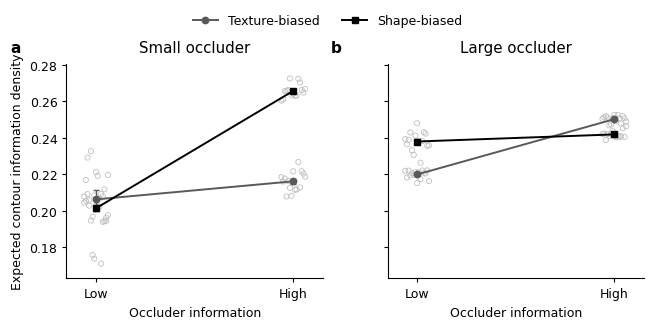

Saved editable SVG to:
/home/hschatzle/monte-carlo-selection/results/contrasts/nature_style_fs_interaction.svg


In [79]:
# %%
# ============================================================
# Nature-style 2-panel interaction plot
# - reads summary_all_cases.csv from all 8 condition folders
# - plots per-run points + mean ± SE
# - saves editable SVG
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/home/hschatzle/monte-carlo-selection/results/contrasts")

CONDITION_DIRS = [
    "bgmm_elephant_texture_low_large",
    "bgmm_elephant_shape_low_large",
    "bgmm_elephant_texture_high_large",
    "bgmm_elephant_shape_high_large",
    "bgmm_elephant_texture_low_small",
    "bgmm_elephant_shape_low_small",
    "bgmm_elephant_texture_high_small",
    "bgmm_elephant_shape_high_small",
]

PRIMARY_METRIC = "expected_fs_hard_density"
OUT_SVG = ROOT / "nature_style_fs_interaction.svg"

# ------------------------------------------------------------
# Load all condition-level run summaries
# ------------------------------------------------------------
dfs = []

for cond in CONDITION_DIRS:
    csv_path = ROOT / cond / "_multicase_fs_summary" / "summary_all_cases.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing file: {csv_path}")

    df = pd.read_csv(csv_path)
    df["condition"] = cond

    # Parse folder name: bgmm_elephant_{network}_{info}_{size}
    parts = cond.split("_")
    network = parts[2]   # texture / shape
    info = parts[3]      # low / high
    size = parts[4]      # small / large

    df["network"] = network
    df["info"] = info
    df["size"] = size

    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

all_df["network"] = pd.Categorical(all_df["network"], categories=["texture", "shape"], ordered=True)
all_df["info"] = pd.Categorical(all_df["info"], categories=["low", "high"], ordered=True)
all_df["size"] = pd.Categorical(all_df["size"], categories=["small", "large"], ordered=True)

# ------------------------------------------------------------
# Aggregate mean and SE for plotting
# ------------------------------------------------------------
summary = (
    all_df
    .groupby(["network", "info", "size"], as_index=False)
    .agg(
        n_runs=("case_id", "count"),
        mean_value=(PRIMARY_METRIC, "mean"),
        sd_value=(PRIMARY_METRIC, lambda x: np.std(x, ddof=1)),
        se_value=(PRIMARY_METRIC, lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
    )
)

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
# Monochrome, Nature-friendly
style_map = {
    "texture": {"color": "0.35", "marker": "o", "label": "Texture-biased"},
    "shape":   {"color": "0.00", "marker": "s", "label": "Shape-biased"},
}

x_map = {"low": 0, "high": 1}
panel_order = ["small", "large"]
panel_title = {"small": "Small occluder", "large": "Large occluder"}

# Shared y-limits with a bit of padding
y = all_df[PRIMARY_METRIC].to_numpy()
ymin = y.min()
ymax = y.max()
ypad = 0.08 * (ymax - ymin)
ylim = (ymin - ypad, ymax + ypad)

plt.rcParams.update({
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "svg.fonttype": "none",   # keep text editable in SVG
})

fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.2), sharey=True)

for ax, size in zip(axes, panel_order):
    panel_df = all_df[all_df["size"] == size].copy()
    panel_summary = summary[summary["size"] == size].copy()

    # per-run points
    for network in ["texture", "shape"]:
        spec = style_map[network]
        net_df = panel_df[panel_df["network"] == network].copy()

        for info in ["low", "high"]:
            sub = net_df[net_df["info"] == info].copy()
            x0 = x_map[info]

            # deterministic jitter so figure is reproducible
            n = len(sub)
            jitter = np.linspace(-0.06, 0.06, n) if n > 1 else np.array([0.0])

            ax.scatter(
                np.full(n, x0) + jitter,
                sub[PRIMARY_METRIC].to_numpy(),
                s=14,
                facecolors="none",
                edgecolors="0.75",
                linewidths=0.6,
                zorder=1
            )

    # mean ± SE lines
    for network in ["texture", "shape"]:
        spec = style_map[network]
        sub = panel_summary[panel_summary["network"] == network].sort_values("info")

        xs = np.array([x_map[i] for i in sub["info"]], dtype=float)
        ys = sub["mean_value"].to_numpy()
        ses = sub["se_value"].to_numpy()

        ax.plot(
            xs, ys,
            color=spec["color"],
            linewidth=1.4,
            marker=spec["marker"],
            markersize=4.6,
            label=spec["label"],
            zorder=3
        )

        ax.errorbar(
            xs, ys, yerr=ses,
            fmt="none",
            ecolor=spec["color"],
            elinewidth=1.0,
            capsize=2.5,
            zorder=2
        )

    # cosmetics
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(*ylim)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Low", "High"])
    ax.set_xlabel("Occluder information")
    ax.set_title(panel_title[size], pad=8)

    # Nature-like minimalist styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

# y-label only once
axes[0].set_ylabel("Expected contour information density")

# panel letters
axes[0].text(-0.22, 1.04, "a", transform=axes[0].transAxes, fontsize=11, fontweight="bold", va="bottom")
axes[1].text(-0.22, 1.04, "b", transform=axes[1].transAxes, fontsize=11, fontweight="bold", va="bottom")

# legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=2,
    frameon=False,
    handlelength=2.0,
    columnspacing=1.8
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save editable SVG
fig.savefig(OUT_SVG, format="svg", bbox_inches="tight")
plt.show()

print("Saved editable SVG to:")
print(OUT_SVG)

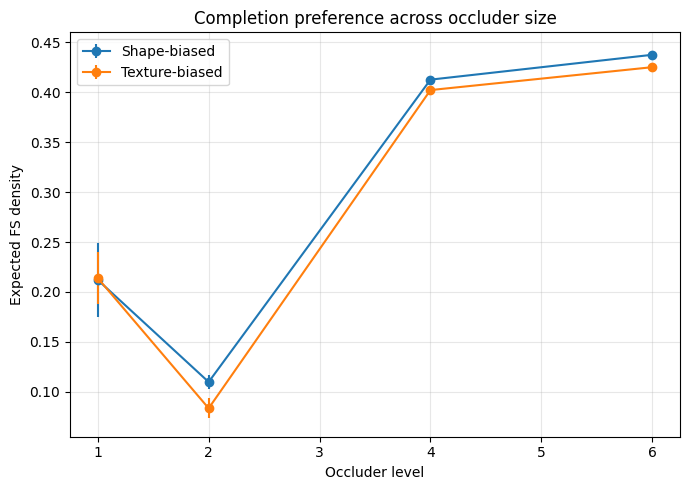

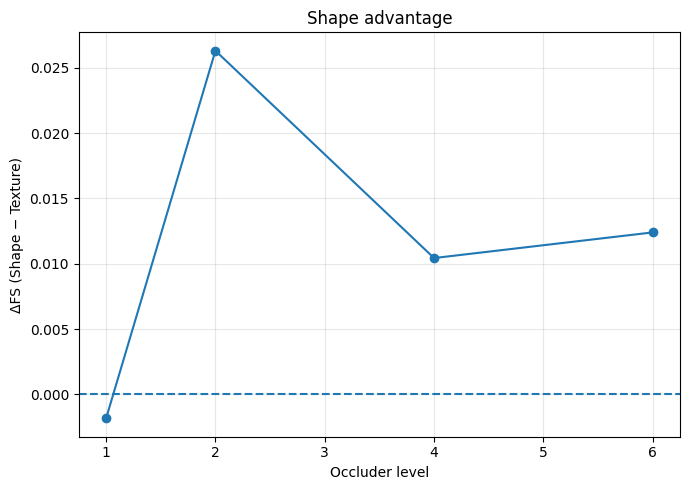

In [128]:
# %%
# ============================================================
# Plot FS curves across occluder levels
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Specify experiment folders
# Each folder must contain: summary_aggregate.csv
# ------------------------------------------------------------
BASE = Path("/home/hschatzle/monte-carlo-selection/results/symmetry")

PATHS = {
    "shape": {
        1: BASE / "bgmm_butterfly_symmetrical_shape_1/_multicase_fs_summary/summary_aggregate.csv",
        2: BASE / "bgmm_butterfly_symmetrical_shape_2/_multicase_fs_summary/summary_aggregate.csv",
        4: BASE / "bgmm_butterfly_symmetrical_shape_4/_multicase_fs_summary/summary_aggregate.csv",
        6: BASE / "bgmm_butterfly_symmetrical_shape_6/_multicase_fs_summary/summary_aggregate.csv",
        #8: BASE / "shape_lvl8/_multicase_fs_summary/summary_aggregate.csv",
    },
    "texture": {
        1: BASE / "bgmm_butterfly_symmetrical_texture_1/_multicase_fs_summary/summary_aggregate.csv",
        2: BASE / "bgmm_butterfly_symmetrical_texture_2/_multicase_fs_summary/summary_aggregate.csv",
        4: BASE / "bgmm_butterfly_symmetrical_texture_4/_multicase_fs_summary/summary_aggregate.csv",
        6: BASE / "bgmm_butterfly_symmetrical_texture_6/_multicase_fs_summary/summary_aggregate.csv",
        #8: BASE / "texture_lvl8/_multicase_fs_summary/summary_aggregate.csv",
    }
}

# ------------------------------------------------------------
# Helper: extract FS density mean
# ------------------------------------------------------------
def load_fs_density(csv_path):

    df = pd.read_csv(csv_path)

    row = df[df["metric"] == "expected_fs_hard_density"]

    if len(row) == 0:
        raise ValueError(f"No expected_fs_hard_density row in {csv_path}")

    return row["mean"].values[0], row["se"].values[0]


# ------------------------------------------------------------
# Load all levels
# ------------------------------------------------------------
levels = sorted(PATHS["shape"].keys())

shape_mean = []
shape_se = []

texture_mean = []
texture_se = []

for lvl in levels:

    m, se = load_fs_density(PATHS["shape"][lvl])
    shape_mean.append(m)
    shape_se.append(se)

    m, se = load_fs_density(PATHS["texture"][lvl])
    texture_mean.append(m)
    texture_se.append(se)


# ------------------------------------------------------------
# Compute delta
# ------------------------------------------------------------
delta = [s - t for s, t in zip(shape_mean, texture_mean)]


# ------------------------------------------------------------
# Plot 1: FS curves
# ------------------------------------------------------------
plt.figure(figsize=(7,5))

plt.errorbar(levels, shape_mean, yerr=shape_se, marker="o", label="Shape-biased")
plt.errorbar(levels, texture_mean, yerr=texture_se, marker="o", label="Texture-biased")

plt.xlabel("Occluder level")
plt.ylabel("Expected FS density")
plt.title("Completion preference across occluder size")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 2: Delta FS
# ------------------------------------------------------------
plt.figure(figsize=(7,5))

plt.plot(levels, delta, marker="o")

plt.axhline(0, linestyle="--")

plt.xlabel("Occluder level")
plt.ylabel("ΔFS (Shape − Texture)")
plt.title("Shape advantage")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()